In [47]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
path = "/content/drive/MyDrive/data/salary_data.csv"

In [49]:
import pandas as pd
import numpy as np


In [50]:
df = pd.read_csv(path)

In [51]:
df.head()

,YearsExperience,Salary
0,0.1,34675.53
1,0.3,38823.22
2,0.4,34213.53
3,0.5,41642.58
4,0.7,26144.61


In [52]:
df.isna().sum()

,0
YearsExperience,0
Salary,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  100 non-null    float64
 1   Salary           100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [54]:
df.describe()

,YearsExperience,Salary
count,100.000000,100.000000
mean,7.052000,65251.357100
std,4.455651,22375.926968
min,0.100000,26144.610000
25%,2.875000,45671.032500
50%,6.950000,61802.715000
75%,10.925000,85012.180000
max,14.800000,110254.580000


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(df[['YearsExperience']], df['Salary'], test_size=0.2, random_state=42)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [58]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [60]:
model.fit(X_train_scaled, y_train)


LinearRegression()

In [61]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[89761.26198887 68675.63523294 82572.98014026 59570.4782247
 58612.04064489 55257.50911554 44714.69573757 87365.16803933
 37047.19509906 32255.00719998 41839.38299813 51423.75879628
 84010.63650998 52861.415166   95991.10625766 35130.31993943
 86406.73045952 87365.16803933 38964.07025869 51902.97758619]


In [62]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8938976963542663

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

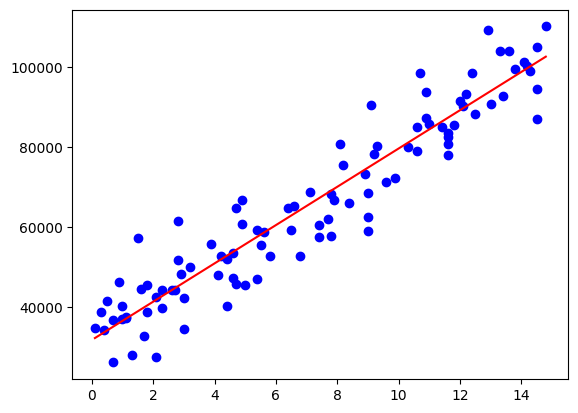

In [64]:
plt.scatter(df["YearsExperience"], df["Salary"], color='blue', label='Actual')
plt.plot(df["YearsExperience"], model.predict(scaler.transform(df[['YearsExperience']])), color='red', label='Predicted')